In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print("Shape:", df.shape)

Shape: (301, 9)


In [4]:
print("Shape:", df.shape)

Shape: (301, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [10]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Kms_Driven       0.0
Fuel_Type        0.0
Seller_Type      0.0
Transmission     0.0
Owner            0.0
dtype: float64

In [12]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [13]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [14]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [15]:
df['Fuel_Type'] = df['Fuel_Type'].str.strip().str.title()
df['Seller_Type'] = df['Seller_Type'].str.strip().str.title()
df['Transmission'] = df['Transmission'].str.strip().str.title()

In [17]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'Cng']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [18]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'Cng']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [19]:
current_year = 2026

df['Car_Age'] = current_year - df['Year']

In [20]:
df['Brand'] = df['Car_Name'].str.split().str[0]

In [21]:
df[['Car_Name', 'Brand']].head(10)

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [22]:
df[['Car_Name', 'Brand']].head(10)

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [23]:
df['Brand'].value_counts()

Brand
city        26
Bajaj       25
Royal       17
corolla     17
Honda       17
Hero        15
verna       14
etios       11
fortuner    11
brio        10
innova       9
ciaz         9
i20          9
Yamaha       8
TVS          8
grand        8
amaze        7
jazz         7
eon          6
ertiga       6
alto         6
sx4          6
i10          5
swift        5
ritz         4
KTM          4
wagon        4
dzire        4
Activa       3
creta        3
xcent        3
elantra      2
ignis        1
vitara       1
s            1
Mahindra     1
Hyosung      1
baleno       1
omni         1
Suzuki       1
camry        1
land         1
UM           1
800          1
Name: count, dtype: int64

In [24]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


In [25]:
df.shape

(301, 11)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
 9   Car_Age        301 non-null    int64  
 10  Brand          301 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 26.0+ KB


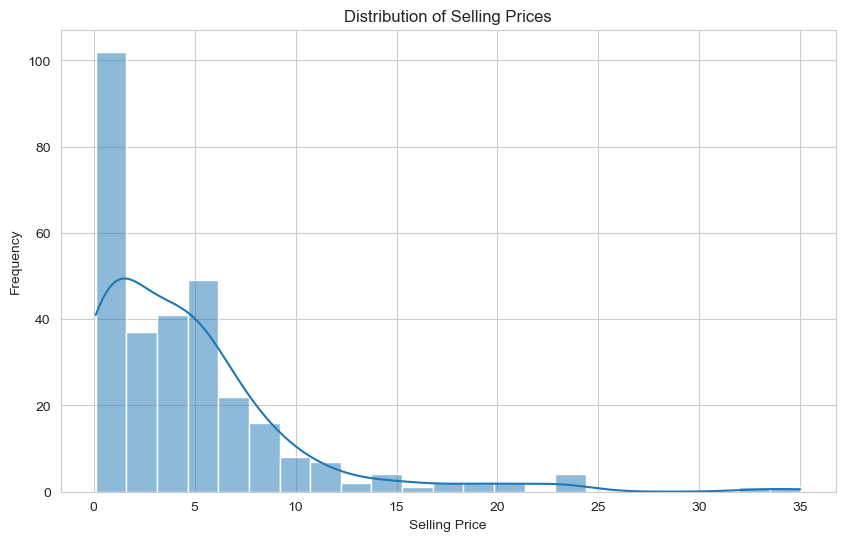

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Selling_Price'],
    kde=True
)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

Observation

The selling-price distribution shows how vehicle prices are distributed in the dataset. If the distribution is right-skewed, most vehicles are concentrated at lower prices while a smaller number of vehicles have substantially higher selling prices.

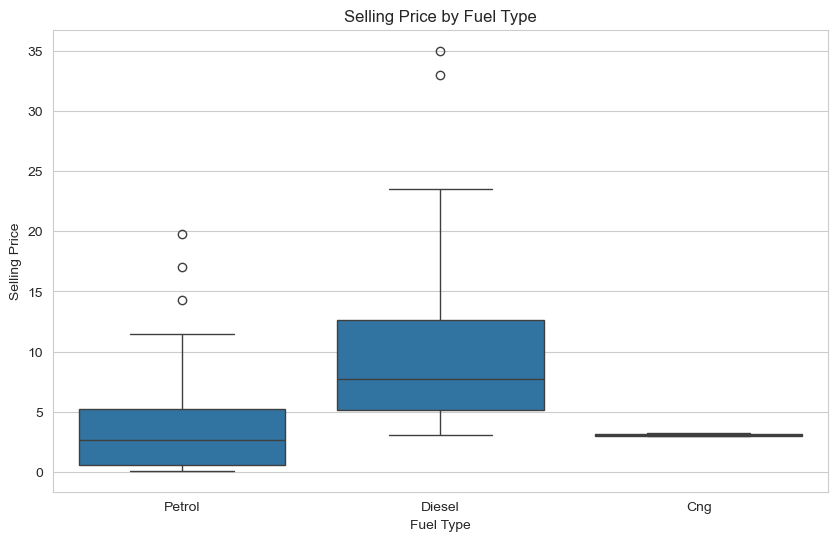

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Fuel_Type',
    y='Selling_Price'
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

Observation

The box plot compares the distribution of selling prices across fuel types. The median and spread of each category can be compared to identify differences in the prices of vehicles using different fuel types.

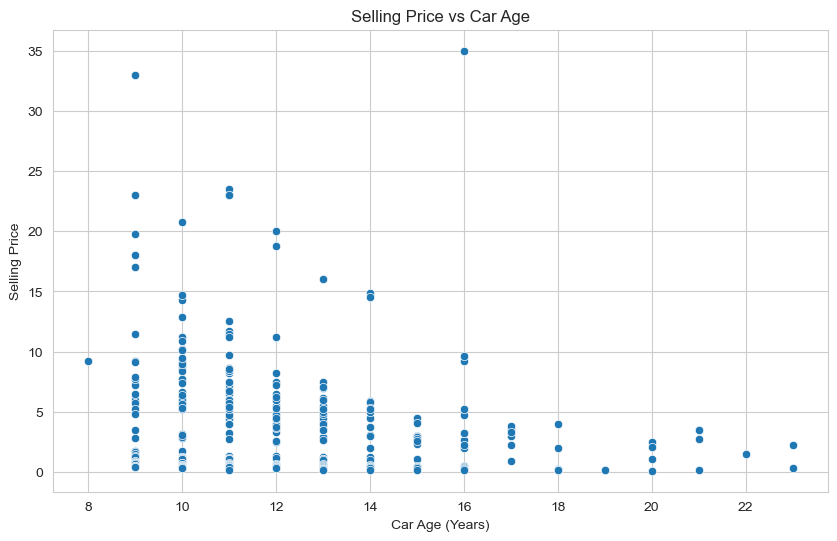

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Car_Age',
    y='Selling_Price'
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.show()

Observation

The scatter plot can be used to examine the relationship between vehicle age and selling price. In general, older vehicles may have lower selling prices, although other factors such as brand, mileage, and present price also influence the final price.

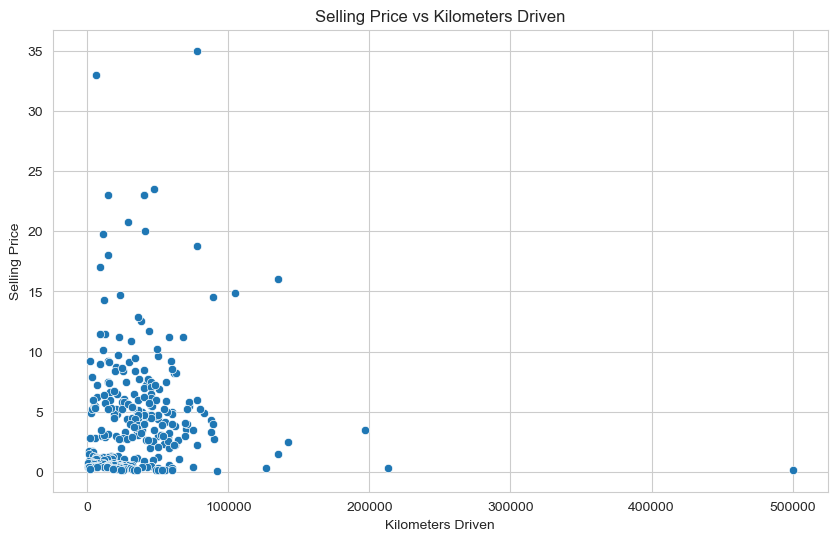

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Kms_Driven',
    y='Selling_Price'
)

plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

In [32]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
Year,1.000000,0.236141,-0.047584,-0.524342,-0.182104,-1.000000
Selling_Price,0.236141,1.000000,0.878983,0.029187,-0.088344,-0.236141
Present_Price,-0.047584,0.878983,1.000000,0.203647,0.008057,0.047584
Kms_Driven,-0.524342,0.029187,0.203647,1.000000,0.089216,0.524342
Owner,-0.182104,-0.088344,0.008057,0.089216,1.000000,0.182104
Car_Age,-1.000000,-0.236141,0.047584,0.524342,0.182104,1.000000


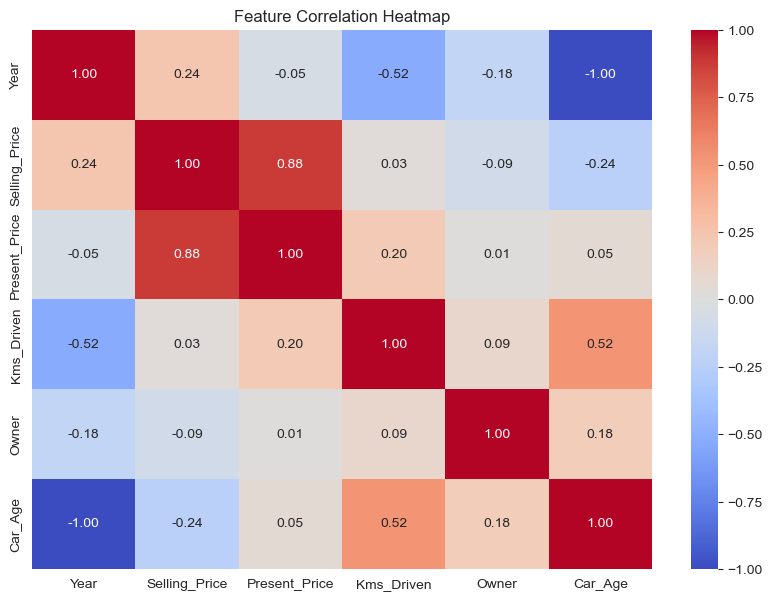

In [33]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

Observation

The correlation heatmap shows the strength and direction of linear relationships between numerical variables. The correlation with Selling_Price can help identify which numerical features have stronger linear associations with the target. Correlation does not necessarily imply causation.

In [35]:
y = df['Selling_Price']

In [36]:
X = df[
    [
        'Present_Price',
        'Kms_Driven',
        'Fuel_Type',
        'Seller_Type',
        'Transmission',
        'Owner',
        'Car_Age',
        'Brand'
    ]
]

In [37]:
X = df[
    [
        'Present_Price',
        'Kms_Driven',
        'Fuel_Type',
        'Seller_Type',
        'Transmission',
        'Owner',
        'Car_Age',
        'Brand'
    ]
]

In [38]:
X.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,6.87,42450,Diesel,Dealer,Manual,0,12,swift


In [39]:
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [40]:
categorical_features = [
    'Fuel_Type',
    'Seller_Type',
    'Transmission',
    'Brand'
]

numerical_features = [
    'Present_Price',
    'Kms_Driven',
    'Owner',
    'Car_Age'
]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 8)
Testing data: (61, 8)


In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [45]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [46]:
linear_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
linear_predictions = linear_model.predict(X_test)

In [48]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
------------------
MAE : 1.060604818046462
RMSE: 1.6304122889677544
R²  : 0.8846027011089893


In [49]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [50]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
rf_predictions = rf_model.predict(X_test)

In [52]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("-------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
-------------
MAE : 0.6227073770491798
RMSE: 0.9393644474882565
R²  : 0.961693806188088


In [53]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        linear_mae,
        rf_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse
    ],
    'R2 Score': [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.060605,1.630412,0.884603
1,Random Forest,0.622707,0.939364,0.961694


In [54]:
preprocessor_fitted = rf_model.named_steps['preprocessor']

feature_names = preprocessor_fitted.get_feature_names_out()

feature_names

array(['cat__Fuel_Type_Cng', 'cat__Fuel_Type_Diesel',
       'cat__Fuel_Type_Petrol', 'cat__Seller_Type_Dealer',
       'cat__Seller_Type_Individual', 'cat__Transmission_Automatic',
       'cat__Transmission_Manual', 'cat__Brand_800', 'cat__Brand_Activa',
       'cat__Brand_Bajaj', 'cat__Brand_Hero', 'cat__Brand_Honda',
       'cat__Brand_Hyosung', 'cat__Brand_KTM', 'cat__Brand_Mahindra',
       'cat__Brand_Royal', 'cat__Brand_Suzuki', 'cat__Brand_TVS',
       'cat__Brand_Yamaha', 'cat__Brand_alto', 'cat__Brand_amaze',
       'cat__Brand_baleno', 'cat__Brand_brio', 'cat__Brand_camry',
       'cat__Brand_ciaz', 'cat__Brand_city', 'cat__Brand_corolla',
       'cat__Brand_creta', 'cat__Brand_dzire', 'cat__Brand_elantra',
       'cat__Brand_eon', 'cat__Brand_ertiga', 'cat__Brand_etios',
       'cat__Brand_fortuner', 'cat__Brand_grand', 'cat__Brand_i10',
       'cat__Brand_i20', 'cat__Brand_ignis', 'cat__Brand_innova',
       'cat__Brand_jazz', 'cat__Brand_land', 'cat__Brand_omni',
       '

In [55]:
importances = rf_model.named_steps['model'].feature_importances_

In [56]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
48,remainder__Present_Price,0.875514
51,remainder__Car_Age,0.057685
49,remainder__Kms_Driven,0.030864
5,cat__Transmission_Automatic,0.005659
33,cat__Brand_fortuner,0.004596
6,cat__Transmission_Manual,0.004363
25,cat__Brand_city,0.003622
26,cat__Brand_corolla,0.002615
2,cat__Fuel_Type_Petrol,0.002572
40,cat__Brand_land,0.002171


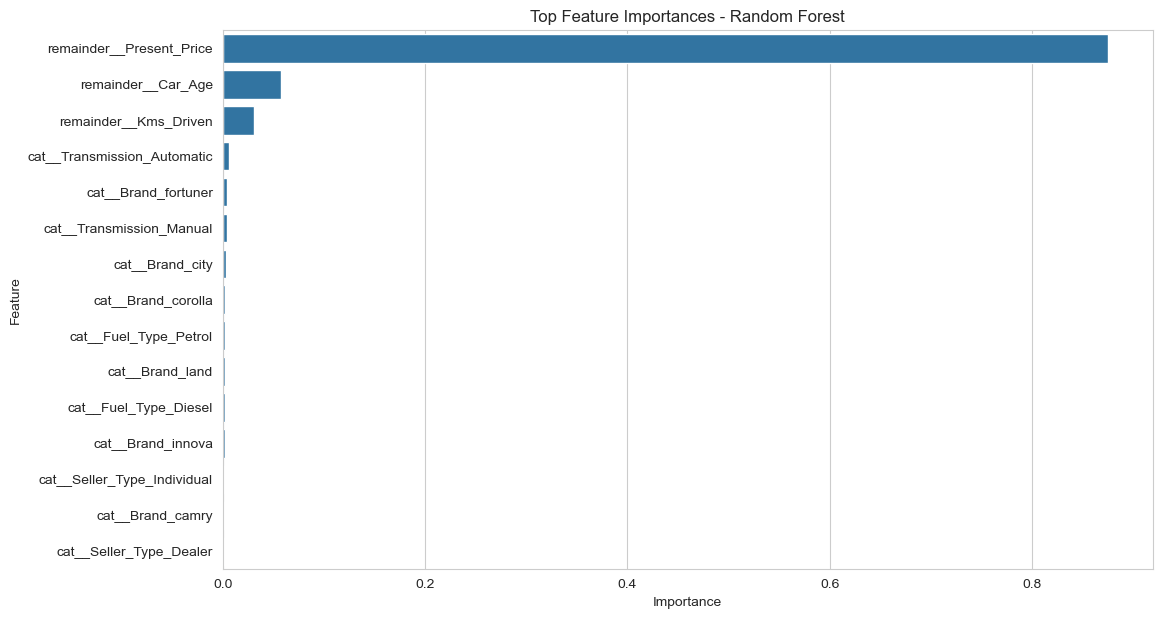

In [57]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Observation

The feature-importance chart shows which input features contributed most to the Random Forest model's predictions. Feature importance is model-specific and should not be interpreted as proof that a feature independently causes changes in selling price.

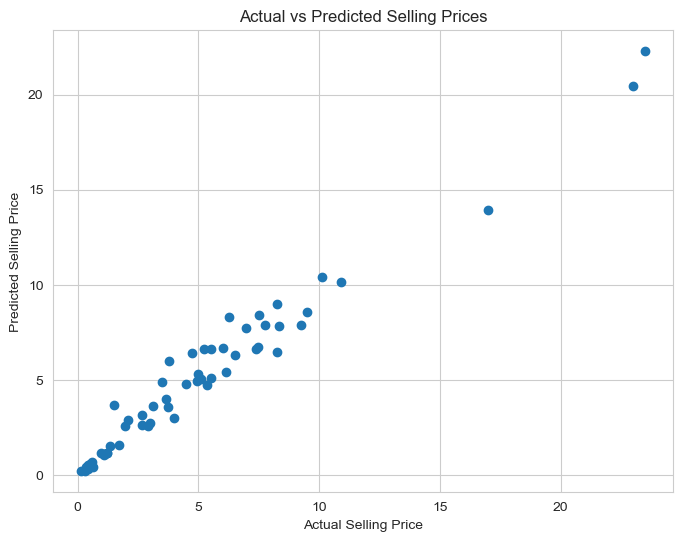

In [58]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Prices")

plt.show()

In [59]:
new_car = pd.DataFrame({
    'Present_Price': [8.5],
    'Kms_Driven': [45000],
    'Fuel_Type': ['Petrol'],
    'Seller_Type': ['Dealer'],
    'Transmission': ['Manual'],
    'Owner': [0],
    'Car_Age': [5],
    'Brand': ['Honda']
})

Conclusion

In this project, a used-car price prediction system was developed using machine-learning regression techniques. The dataset was cleaned by handling missing values, removing duplicate records, and standardizing categorical values.

Feature engineering was performed by calculating car age from the manufacturing year and extracting a brand-related feature from the car name.

Exploratory data analysis was used to examine selling-price distributions and relationships between selling price, fuel type, car age, and other vehicle characteristics.

Two regression models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² score.

The model comparison should be based on the actual test-set metrics. Lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates that more variation in the target was explained by the model.

Finally, feature importance analysis was performed to understand which input features were most influential in the Random Forest model.